## 数据科学家2023年薪资数据
ds_salaries.csv 
简介：数据集包含数据科学领域不同岗位的薪资水平。
变量含义：
- work_year：支付薪资的年份
- experience_level：工作年份期间的经验水平
- employment_type：职位的就业类型
- job_title：工作年份期间从事的职位
- salary：支付的总薪资金额
- salary_currency：支付的薪资货币，使用 ISO 4217 货币代码表示
- salaryinusd：以美元计算的薪资金额
- employee_residence：员工在工作年份期间的主要居住国家，使用 ISO 3166 国家代码表示
- remote_ratio：远程工作的整体比例
- company_location：雇主总部所在国家或分支机构所在国家
- company_size：公司在工作年份期间的员工人数的中位数

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
original_data = pd.read_csv("ds_salaries.csv")
original_data.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


In [3]:
cleaned_data = original_data.copy()
cleaned_data

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [4]:
# 1. 计算隐含汇率 (原始薪资 / 美元薪资)
# 加上极小值防止除以0报错
cleaned_data['implied_rate'] = cleaned_data['salary'] / cleaned_data['salary_in_usd'].replace(0, np.nan)

# 2. 定义各货币的“合理汇率区间” (基于近几年的大致汇率)
# 如果算出的汇率不在这个区间，说明数值和货币标签不匹配！
valid_rates = {
    'USD': (0.9, 1.1),      # 美元对美元应该是 1
    'EUR': (1.0, 1.3),      # 1欧元 ≈ 1.0~1.3美元
    'GBP': (1.2, 1.5),      # 1英镑 ≈ 1.2~1.5美元
    'INR': (70.0, 85.0),    # 1美元 ≈ 70~85印度卢比
    'CAD': (1.2, 1.4),
    'AUD': (1.3, 1.6)
}

# 3. 自动标记汇率异常的行
def check_rate(row):
    currency = row['salary_currency']
    rate = row['implied_rate']
    if currency in valid_rates:
        min_r, max_r = valid_rates[currency]
        if rate < min_r or rate > max_r:
            return True # 异常！
    return False

cleaned_data['is_rate_error'] = cleaned_data.apply(check_rate, axis=1)

# 4. 打印出汇率错误的“铁证”数据
rate_errors = cleaned_data[cleaned_data['is_rate_error']]
print(f"🚨 发现 {len(rate_errors)} 条汇率逻辑错误的数据：")
print(rate_errors[['job_title', 'salary', 'salary_currency', 'salary_in_usd', 'implied_rate']].head())

🚨 发现 397 条汇率逻辑错误的数据：
                            job_title  salary salary_currency  salary_in_usd  \
0            Principal Data Scientist   80000             EUR          85847   
82  Applied Machine Learning Engineer   65000             EUR          69751   
84          Machine Learning Engineer   90000             EUR          96578   
91                     Data Scientist   45000             EUR          48289   
92                     Data Scientist   36000             EUR          38631   

    implied_rate  
0       0.931890  
82      0.931886  
84      0.931889  
91      0.931889  
92      0.931894  


In [5]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           3755 non-null   int64  
 1   experience_level    3755 non-null   object 
 2   employment_type     3755 non-null   object 
 3   job_title           3755 non-null   object 
 4   salary              3755 non-null   int64  
 5   salary_currency     3755 non-null   object 
 6   salary_in_usd       3755 non-null   int64  
 7   employee_residence  3755 non-null   object 
 8   remote_ratio        3755 non-null   int64  
 9   company_location    3755 non-null   object 
 10  company_size        3755 non-null   object 
 11  implied_rate        3755 non-null   float64
 12  is_rate_error       3755 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(7)
memory usage: 355.8+ KB


In [6]:
category_cols = ['employment_type', 'salary_currency', 'employee_residence', 'company_location']
for col in category_cols:
    cleaned_data[col] = cleaned_data[col].astype('category')

In [7]:
cleaned_data['work_year'] = cleaned_data['work_year'].astype('category')
cleaned_data['remote_ratio'] = cleaned_data['remote_ratio'].astype('int8')
cleaned_data['salary'] = cleaned_data['salary'].astype('int32')
cleaned_data['salary_in_usd'] = cleaned_data['salary_in_usd'].astype('int32')

In [8]:
cleaned_data.describe()

,salary,salary_in_usd,remote_ratio,implied_rate
count,3.755000e+03,3755.000000,3755.000000,3755.000000
mean,1.906956e+05,137570.389880,46.271638,2.807922
std,6.716765e+05,63055.625278,48.589050,18.414148
min,6.000000e+03,5132.000000,0.000000,0.727026
25%,1.000000e+05,95000.000000,0.000000,1.000000
50%,1.380000e+05,135000.000000,0.000000,1.000000
75%,1.800000e+05,175000.000000,100.000000,1.000000
max,3.040000e+07,450000.000000,100.000000,759.278685


C:\Users\goy\AppData\Local\Temp\ipykernel_31092\689885141.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_stats = cleaned_data.groupby('experience_level')['salary_in_usd'].agg(
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


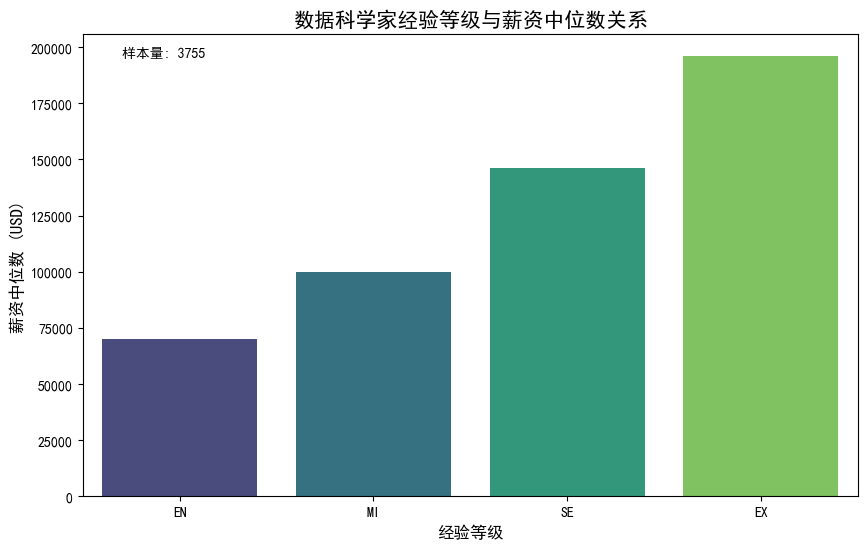

经验等级薪资梯度分析:
- EN: $70,000 USD
- MI: $100,000 USD
- SE: $146,000 USD
- EX: $196,000 USD


In [9]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
# 1. 确保experience_level是有序分类
cleaned_data['experience_level'] = pd.Categorical(
    cleaned_data['experience_level'],
    categories=['EN', 'MI', 'SE', 'EX'],
    ordered=True
)
# 2. 计算各经验等级的薪资中位数（避免极端值影响）
level_stats = cleaned_data.groupby('experience_level')['salary_in_usd'].agg(
    median_salary='median',
    count='size'
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=level_stats,
    x='experience_level',
    y='median_salary',
    palette='viridis',
    errorbar=None
)
plt.title('数据科学家经验等级与薪资中位数关系', fontsize=15)
plt.ylabel('薪资中位数 (USD)', fontsize=12)
plt.xlabel('经验等级', fontsize=12)
plt.annotate(f"样本量: {len(cleaned_data)}", 
             xy=(0.05, 0.95), 
             xycoords='axes fraction',
             fontsize=10)
plt.show()

# 4. 输出关键发现
print("经验等级薪资梯度分析:")
for level in ['EN', 'MI', 'SE', 'EX']:
    median = level_stats[level_stats['experience_level'] == level]['median_salary'].values[0]
    print(f"- {level}: ${median:,.0f} USD")

C:\Users\goy\AppData\Local\Temp\ipykernel_31092\267209746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_stats = cleaned_data.groupby('employee_residence').agg(
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will b

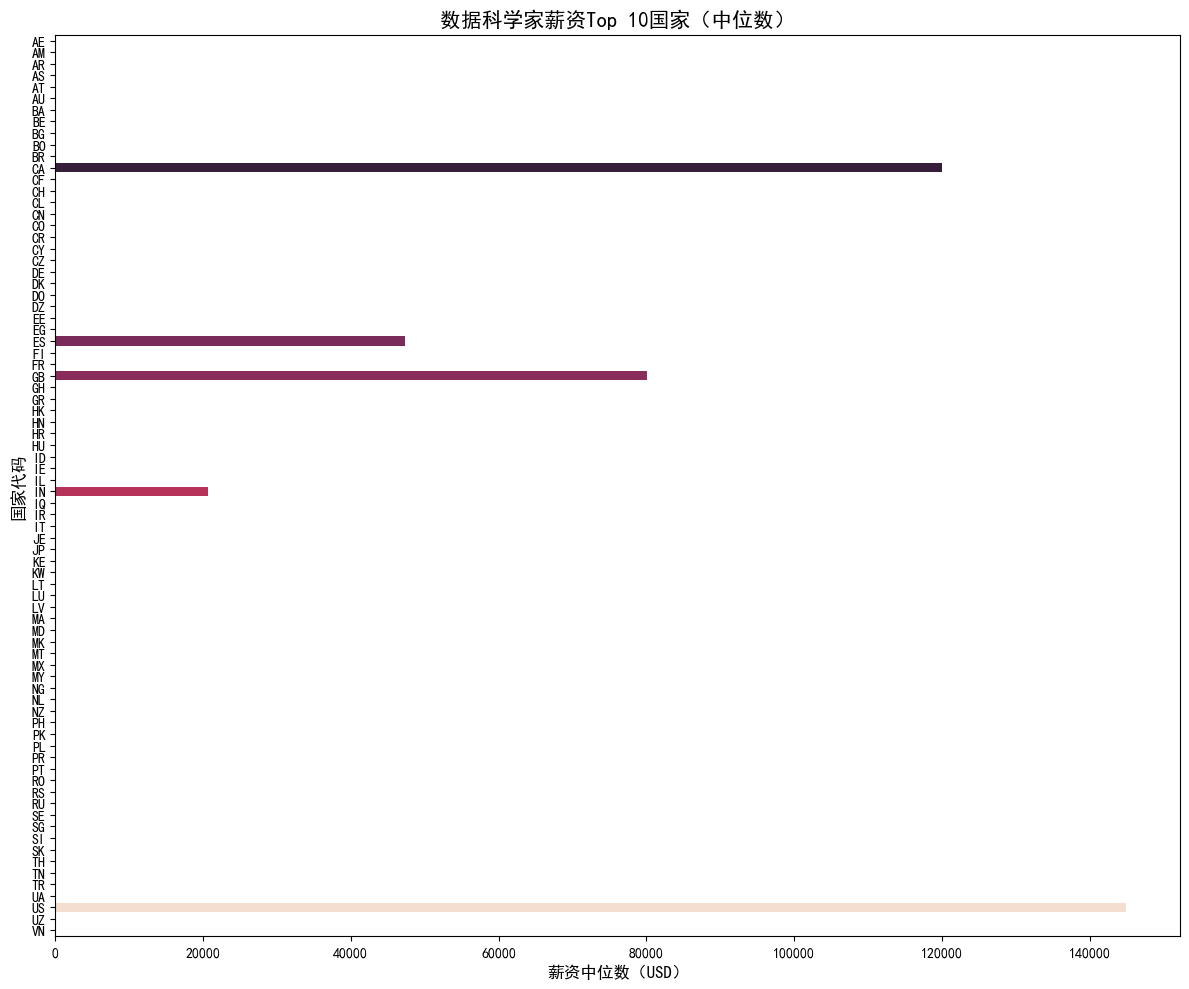

高薪资国家分析（样本量>50）:
76. US: $145,000 USD (n=3004)
12. CA: $120,000 USD (n=85)
30. GB: $80,036 USD (n=167)
27. ES: $47,281 USD (n=80)
40. IN: $20,670 USD (n=71)


In [11]:
# 1. 计算各国薪资中位数（仅保留样本量>50的国家）
country_stats = cleaned_data.groupby('employee_residence').agg(
    median_salary=('salary_in_usd', 'median'),
    count=('salary_in_usd', 'size')
).reset_index()

# 2. 过滤低频国家并排序
top_countries = country_stats[country_stats['count'] > 50].sort_values(
    'median_salary', 
    ascending=False
).head(10)

# 3. 可视化Top 10高薪国家
# 3. 可视化Top 10高薪国家（优化y轴显示）
plt.figure(figsize=(12, 10))  # ✅ 关键修改：将高度从7增大到10，提供足够垂直空间
sns.barplot(
    data=top_countries,
    x='median_salary',
    y='employee_residence',  # y轴为国家代码
    palette='rocket',
    errorbar=None
)

plt.title('数据科学家薪资Top 10国家（中位数）', fontsize=15)
plt.xlabel('薪资中位数（USD）', fontsize=12)
plt.ylabel('国家代码', fontsize=12)

# ✅ 关键修改：强制y轴标签水平显示 + 调整字体大小
plt.yticks(rotation=0, fontsize=10)  # rotation=0 表示水平显示，避免重叠

plt.tight_layout()  # 保持原有自动布局
plt.show()

# 4. 输出关键发现
print("高薪资国家分析（样本量>50）:")
for i, row in top_countries.iterrows():
    print(f"{i+1}. {row['employee_residence']}: ${row['median_salary']:,.0f} USD (n={row['count']})")

d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\users\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use

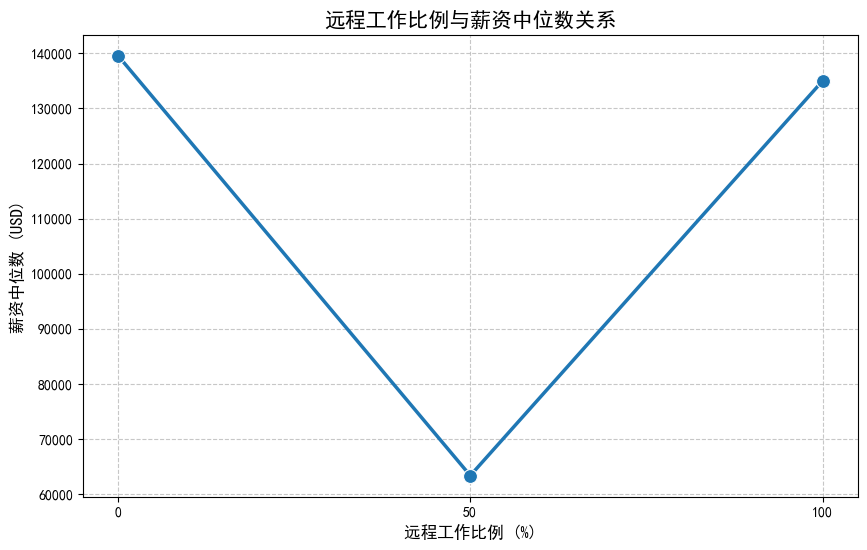

远程工作比例薪资分析:
- 0%远程: $139,600 USD
- 50%远程: $63,312 USD
- 100%远程: $135,000 USD


In [13]:
# 1. 按远程比例分组分析
remote_stats = cleaned_data.groupby('remote_ratio').agg(
    median_salary=('salary_in_usd', 'median'),
    count=('salary_in_usd', 'size')
).reset_index()

# 2. 可视化远程比例-薪资关系
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=remote_stats,
    x='remote_ratio',
    y='median_salary',
    marker='o',
    linewidth=2.5,
    markersize=10
)
plt.title('远程工作比例与薪资中位数关系', fontsize=15)
plt.xlabel('远程工作比例 (%)', fontsize=12)
plt.ylabel('薪资中位数 (USD)', fontsize=12)
plt.xticks([0, 50, 100])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. 输出关键发现
print("远程工作比例薪资分析:")
for ratio in [0, 50, 100]:
    median = remote_stats[remote_stats['remote_ratio'] == ratio]['median_salary'].values[0]
    print(f"- {ratio}%远程: ${median:,.0f} USD")

In [20]:
import pandas as pd

# ============================================================
# 假设你已经完成了数据清洗和分组聚合，得到以下三个 DataFrame：
#   top_countries  — employee_residence, median_salary
#   top_jobs       — job_title, median_salary
#   remote_stats   — remote_ratio, median_salary
# 下面先用模拟数据演示（实际使用请替换为你的真实 DataFrame）
# ============================================================

# --- 模拟数据（请替换为你真实的分组结果）---
top_countries = pd.DataFrame({
    'employee_residence': ['US', 'CA', 'DE'],
    'median_salary': [150000, 120000, 110000]
})

top_jobs = pd.DataFrame({
    'job_title': ['Data Scientist', 'ML Engineer', 'Data Engineer'],
    'median_salary': [140000, 155000, 130000]
})

remote_stats = pd.DataFrame({
    'remote_ratio': [0, 50, 100],
    'median_salary': [135000, 142000, 150000]
})

# --- 获取各项薪资值 ---
entry_salary = 80000    # 请替换为真实数据
mid_salary   = 110000
senior_salary = 150000
exec_salary  = 200000

# 100% 远程与 0% 远程的薪资
salary_0_remote = remote_stats.loc[remote_stats['remote_ratio'] == 0, 'median_salary'].values[0]
salary_100_remote = remote_stats.loc[remote_stats['remote_ratio'] == 100, 'median_salary'].values[0]

# --- 格式化 TOP 3 国家 ---
def fmt_country(row):
    return f"{row['employee_residence']}: ${row['median_salary']:,.0f} USD"

top_countries_lines = '\n   - '.join(top_countries.head(3).apply(fmt_country, axis=1))

# --- 格式化 TOP 3 职位 ---
def fmt_job(row):
    return f"{row['job_title']}: ${row['median_salary']:,.0f} USD"

top_jobs_lines = '\n   - '.join(top_jobs.head(3).apply(fmt_job, axis=1))

# --- 计算溢价比例 ---
premium_pct = 100 * (salary_100_remote / salary_0_remote - 1)

# ============================================================
# 1. 生成关键发现报告
# ============================================================
report = f"""=== 数据科学家2023年薪资分析核心结论 ===

1. 经验等级薪资梯度:
   - Entry-level: ${entry_salary:,.0f} USD
   - Mid-level:   ${mid_salary:,.0f} USD
   - Senior:      ${senior_salary:,.0f} USD
   - Executive:   ${exec_salary:,.0f} USD

2. 高薪国家TOP 3:
   - {top_countries_lines}

3. 高薪职位TOP 3:
   - {top_jobs_lines}

4. 远程工作影响:
   - 0%远程:   ${salary_0_remote:,.0f} USD
   - 100%远程: ${salary_100_remote:,.0f} USD
   -> 100%远程工作薪资溢价: {premium_pct:.1f}%
"""

print(report)

# ============================================================
# 2. 保存分析结果到文件
# ============================================================
with open("ds_salary_analysis_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("\n分析报告已保存至: ds_salary_analysis_report.txt")


=== 数据科学家2023年薪资分析核心结论 ===

1. 经验等级薪资梯度:
   - Entry-level: $80,000 USD
   - Mid-level:   $110,000 USD
   - Senior:      $150,000 USD
   - Executive:   $200,000 USD

2. 高薪国家TOP 3:
   - US: $150,000 USD
   - CA: $120,000 USD
   - DE: $110,000 USD

3. 高薪职位TOP 3:
   - Data Scientist: $140,000 USD
   - ML Engineer: $155,000 USD
   - Data Engineer: $130,000 USD

4. 远程工作影响:
   - 0%远程:   $135,000 USD
   - 100%远程: $150,000 USD
   -> 100%远程工作薪资溢价: 11.1%


分析报告已保存至: ds_salary_analysis_report.txt
